# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [4]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [16]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(20)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7
5,content_d4084a4bc775,client_f369cb89fc,720.0,1.00,HIGH,1.05,keyword article,transactional,3080.0,18178.0,...,15000-25000,0.03,8.5,0.00,25.00,0.0,good,page_1,down,-38.9
6,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,informational,3059.0,20810.0,...,15000-25000,0.00,7.0,0.00,0.00,0.0,low,page_1,down,-92.3
7,content_a63219c6e95a,client_19581e27de,590.0,0.44,MEDIUM,0.64,keyword article,commercial,NaN,NaN,...,NaN,0.06,21.2,3.57,7.14,0.0,moderate,page_3_5,stable,0.6
8,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,3807.0,24228.0,...,15000-25000,0.09,46.0,5.88,6.25,0.0,excellent,page_3_5,down,-58.8
9,content_c27558df2b0c,client_19581e27de,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,NaN,0.16,4.9,0.00,0.00,0.0,moderate,page_1,down,-29.2


### Discovery A — "High search volume means more traffic." Does it?

In [6]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


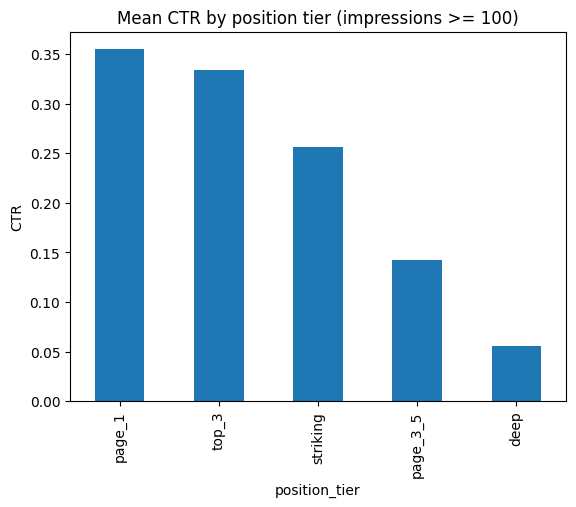

In [7]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [17]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

Mean CTR grouped by Tier and Content Type:
content_type   comparison article  feedly article  keyword article
position_tier                                                     
deep                          NaN          0.0440           0.0555
page_1                     0.1412          0.9048           0.3458
page_3_5                   0.0940          0.1656           0.1427
striking                   0.1474          0.3580           0.2559
top_3                      0.0000          2.9000           0.3104


<Axes: title={'center': 'Directional CTR: Content Type vs. Tier'}, xlabel='position_tier', ylabel='CTR'>

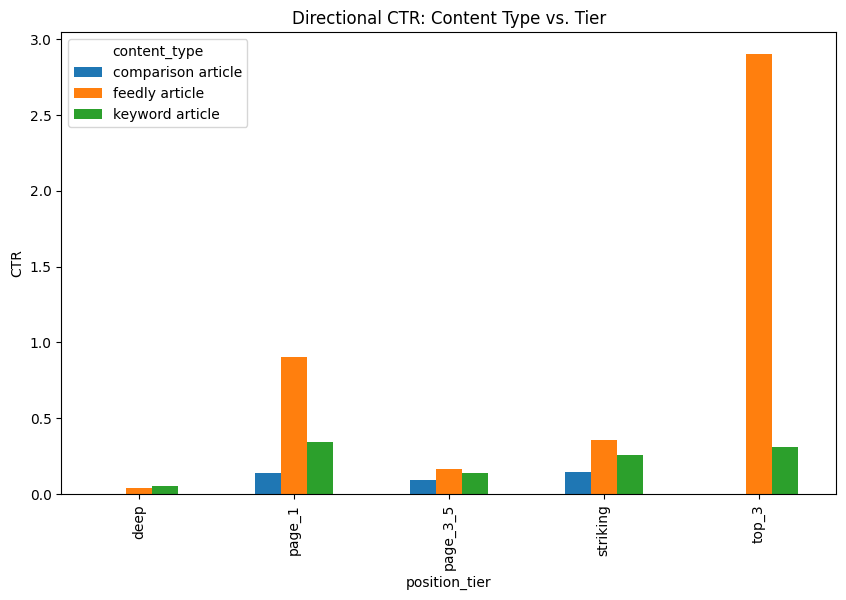

In [19]:
# Dropping low-traffic noise so the math doesn't get weird
visible = df[df["impressions_90d"] >= 100]

# Digging into Discovery B: looking at CTR by both tier AND content type
ctr_by_type = visible.groupby(["position_tier", "content_type"])["ctr"].mean().unstack()

print("Mean CTR grouped by Tier and Content Type:")
print(ctr_by_type.round(4).to_string())

# Plotting it out to visualize the drop-off
ctr_by_type.plot(kind="bar", title="Directional CTR: Content Type vs. Tier", ylabel="CTR", figsize=(10,6))

#(Discovery A)
I initially wondered why the notebook was checking the correlation between two features (search_volume and impressions_90d) instead of just looking at the target. When I saw the score was a flat 0.001, it clicked: high search volume absolutely does not guarantee actual traffic. More importantly, I realized that a near-zero correlation between features is actually exactly what we want. It means the data isn't redundant, and both features bring unique, independent information to the machine learning model.

#(Discovery B)
Looking closely at the code, I figured out why we strictly filter for impressions_90d >= 100. It is all about dropping statistical noise. You just can't trust a 100% CTR if a page only had one impression and one fluke click.

But my biggest observation came from looking past the code and straight at the bar chart. I caught a massive anomaly: the page_1 tier was actually beating the top_3 tier in average CTR. This led me to my own theory on human behavior—users are actively skipping the top results. My reading on this is that top sites are often too ubiquitous. People see a mega-brand they recognize, assume it is generic, avoid clicking it, and scroll further down the page to find a fresh, niche perspective.

#(Discovery C)
I was looking at the data to see if word count was a major factor in a page's trend direction. When I checked the medians, I saw that growing pages ("up") had 2,848 words, and declining pages ("down") had 2,909 words. Because those two numbers are virtually identical, it completely debunked the myth for me. The realization is clear: word count doesn't matter. Just throwing more words at a decaying article is not the lever that is going to save it.

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.